# Euro500 Equity Portfolio

This notebook constructs a quarterly rebalanced equity portfolio with 500 firms from the euro-area universe.

Core idea:
- Start from a broad equity universe in LSEG Workspace
- Apply transparent filters (country, listing, instrument type: ordinary/common/preference-style shares)
- Keep the top 500 by free-float market cap each quarter
- Build a quarterly rebalanced top-500 euro-area equity portfolio

Main outputs:
- `euro500.parquet` (quarterly constituents)
- `euro500_daily_returns.parquet` (firm-level daily returns while in index)



## 0. Setup

What this section does:
- Imports core libraries (`pandas`, `numpy`, plotting)
- Initializes the LSEG session
- Defines project paths and output locations
- Sets global parameters used in later steps

Note:
- Running this notebook requires an active local Workspace/LSEG connection.


In [1]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend
set_global_plot_style()

# --- Output paths (anpassen) ---
BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
(DATA_DIR := BASE_DIR / "intermediate").mkdir(parents=True, exist_ok=True)
(CACHE_DATA_DIR := BASE_DIR / "cache").mkdir(parents=True, exist_ok=True)

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)

# --- Shared helper functions (used across sections) ---
def normalize_ric(x: pd.Series) -> pd.Series:
    s = x.astype(str).str.strip().str.upper()
    s = s.str.replace(r"\^.*$", "", regex=True)
    s = s.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    return s


def _best_col(df: pd.DataFrame, candidates: list[str]):
    cols = list(df.columns)
    lower = {str(c).lower(): c for c in cols}
    for c in candidates:
        if c in df.columns:
            return c
        cl = str(c).lower()
        if cl in lower:
            return lower[cl]
    return None


def _to_num(s):
    # Some LSEG pulls contain duplicate column labels; selection by label can return DataFrames.
    # Convert by position (iloc) to guarantee 1-D conversion before coalescing.
    if isinstance(s, pd.DataFrame):
        if s.shape[1] == 0:
            return pd.Series(np.nan, index=s.index, dtype="float64")
        cols = [pd.to_numeric(s.iloc[:, j], errors="coerce") for j in range(s.shape[1])]
        x = pd.concat(cols, axis=1)
        return x.bfill(axis=1).iloc[:, 0]

    if isinstance(s, pd.Series):
        return pd.to_numeric(s, errors="coerce")

    if isinstance(s, pd.Index):
        return pd.to_numeric(pd.Series(s.to_numpy()), errors="coerce")

    if isinstance(s, (list, tuple, set, np.ndarray)):
        vals = np.asarray(list(s) if isinstance(s, set) else s, dtype="object").ravel()
        return pd.to_numeric(pd.Series(vals), errors="coerce")

    return pd.to_numeric(pd.Series([s]), errors="coerce")


def _to_1d(s):
    """Ensure 1-D Series when a label-select returns duplicate columns."""
    if isinstance(s, pd.DataFrame):
        if s.shape[1] == 0:
            return pd.Series(pd.NA, index=s.index, dtype="object")
        return s.bfill(axis=1).iloc[:, 0]
    return s


def _to_num_mixed(s):
    """More permissive numeric parser for fields that may arrive as formatted text."""
    base = _to_num(s)

    raw = _to_1d(s)
    if isinstance(raw, pd.Series):
        txt = raw.astype("string").str.strip()
    else:
        txt = pd.Series(raw, dtype="string").str.strip()

    txt = txt.str.replace(" ", "", regex=False)
    txt = txt.str.replace(" ", "", regex=False)
    txt = txt.str.replace("'", "", regex=False)

    has_dot = txt.str.contains(r"\.", na=False)
    has_comma = txt.str.contains(",", na=False)
    txt = txt.where(~(has_dot & has_comma), txt.str.replace(",", "", regex=False))
    txt = txt.where(~((~has_dot) & has_comma), txt.str.replace(",", ".", regex=False))

    txt = txt.str.replace(r"[^0-9eE+\-.]", "", regex=True)
    alt = pd.to_numeric(txt, errors="coerce")

    if isinstance(base, pd.Series):
        return base.combine_first(alt)
    return alt


def _pick_mcap_with_source(
    mcap_company: pd.Series,
    mcap_local: pd.Series,
    mcap_synth: pd.Series,
    synth_label: str = "price_x_shares",
) -> tuple[pd.Series, pd.Series]:
    mcap = mcap_company.combine_first(mcap_local).combine_first(mcap_synth)
    source = pd.Series(pd.NA, index=mcap.index, dtype="string")
    source = source.mask(mcap_company.notna(), "company_market_cap")
    source = source.mask(mcap_company.isna() & mcap_local.notna(), "market_cap_local_curn")
    source = source.mask(mcap_company.isna() & mcap_local.isna() & mcap_synth.notna(), synth_label)
    return mcap, source


def _sanitize_synth_mcap(
    px: pd.Series,
    shares: pd.Series,
    freefloat: pd.Series | None = None,
    freefloat_pct: pd.Series | None = None,
    max_price_eur: float = 5000.0,
    max_shares: float = 2.0e11,
    ff_ratio_tol: float = 50.0,
) -> pd.Series:
    """
    Guard synthetic market-cap fallback (price*shares) against unit/scale artifacts.

    - Hard caps extreme close prices and share counts.
    - If FreeFloat and FreeFloatPct are present, enforce rough consistency to shares.
    """
    px = _to_num(px)
    shares = _to_num(shares)

    ok_price = px.notna() & px.gt(0) & px.le(max_price_eur)
    ok_shares = shares.notna() & shares.gt(0) & shares.le(max_shares)
    mcap_synth = (px * shares).where(ok_price & ok_shares)

    if freefloat is None or freefloat_pct is None:
        return mcap_synth

    ff = _to_num(freefloat)
    ffp = _to_num(freefloat_pct)
    ff_expected = shares * (ffp / 100.0)

    has_ff_info = ff.notna() & ff.gt(0) & ff_expected.notna() & ff_expected.gt(0)
    ratio = (ff / ff_expected).where(has_ff_info)
    ff_consistent = ratio.between(1.0 / ff_ratio_tol, ff_ratio_tol)

    return mcap_synth.where(~has_ff_info | ff_consistent)


## 1. Definition of the Investment Universe

This section defines the investable starting universe before any portfolio construction.

Design goal:
- A consistent and reproducible euro-area equity universe across the full sample.


### 1.1 Euro-Area Headquartered Firms

Baseline universe criteria:
- Publicly listed active equities
- Primary instruments
- Company headquarters located in euro-area countries

Why this matters:
- Keeps geographic exposure aligned with the research design
- Avoids mixing in non-euro-headquartered firms with different macro exposure

Instrument-type policy (default):
- Exclude `Depositary Receipts` (ADR/GDR/DR)
- Exclude `Stapled Securities`



In [2]:
import pandas as pd

EURO_ADOPTION = {
    # Founding members (book money from 1999-01-01)
    "AT": "1999-01-01",
    "BE": "1999-01-01",
    "FI": "1999-01-01",
    "FR": "1999-01-01",
    "DE": "1999-01-01",
    "IE": "1999-01-01",
    "IT": "1999-01-01",
    "LU": "1999-01-01",
    "NL": "1999-01-01",
    "PT": "1999-01-01",
    "ES": "1999-01-01",

    # Later entrants
    "GR": "2001-01-01",
    "SI": "2007-01-01",
    "CY": "2008-01-01",
    "MT": "2008-01-01",
    "SK": "2009-01-01",
    "EE": "2011-01-01",
    "LV": "2014-01-01",
    "LT": "2015-01-01",
    "HR": "2023-01-01",
}

EURO_ADOPTION_DT = {k: pd.Timestamp(v) for k, v in EURO_ADOPTION.items()}

# Irrevocable legacy currency conversion rates (legacy units per 1 EUR).
# Used to correct transition-day pulls where market cap can still arrive in legacy currency.
EURO_LEGACY_PER_EUR = {
    "AT": 13.7603,
    "BE": 40.3399,
    "FI": 5.94573,
    "FR": 6.55957,
    "DE": 1.95583,
    "IE": 0.787564,
    "IT": 1936.27,
    "LU": 40.3399,
    "NL": 2.20371,
    "PT": 200.482,
    "ES": 166.386,
    "GR": 340.75,
    "SI": 239.64,
    "CY": 0.585274,
    "MT": 0.4293,
    "SK": 30.1260,
    "EE": 15.6466,
    "LV": 0.702804,
    "LT": 3.45280,
    "HR": 7.53450,
}

def euro_hq_codes_for_quarter(formation_date: pd.Timestamp) -> list[str]:
    """
    Countries eligible for the euro area in the return period
    following the portfolio formation date.

    For pre-1999 quarters (used for lag construction), fall back to the
    initial euro members (adoption at the earliest adoption date).
    """
    eligibility_date = formation_date + pd.Timedelta(days=1)
    eligible = sorted(
        c for c, d in EURO_ADOPTION_DT.items()
        if d <= eligibility_date
    )
    if eligible:
        return eligible

    first_adoption = min(EURO_ADOPTION_DT.values())
    return sorted(c for c, d in EURO_ADOPTION_DT.items() if d == first_adoption)

# Broad common-equity filter (historical labels differ across years/venues)
COMMON_EQUITY_TYPE_PATTERNS = [
    "preference",
    "ordinary",
    "common",
    "registered",
    "voting",
    "aandeel",
    "aktion",
]

EXCLUDED_TYPE_PATTERNS = [
    "etf",
    "fund",
    "warrant",
    "certificate",
    "adr",
    "gdr",
    "unit",
    "right",
    "index",
]

def is_common_equity_type(series: pd.Series) -> pd.Series:
    # Some instruments have missing InstrumentType in historical pulls.
    # Keep missing/blank types, and apply pattern filters where labels exist.
    x = series.astype("string").str.strip()
    missing = x.isna() | (x == "")
    s = x.str.lower().fillna("")

    keep = missing.copy()
    for pat in COMMON_EQUITY_TYPE_PATTERNS:
        keep = keep | s.str.contains(pat, na=False)
    for pat in EXCLUDED_TYPE_PATTERNS:
        keep = keep & ~s.str.contains(pat, na=False)
    return keep








### 1.1B Screen Builder

Here the LSEG Screener query is assembled.

The screen defines:
- Entity type and active status
- Region/country constraints
- Instrument-level restrictions

Output of this step:
- A reusable screen template used for each quarter in the sample loop.


In [3]:
def make_screen_euro_all_for_quarter(formation_date: pd.Timestamp) -> str:
    """
    SCREEN universe for euro-area headquartered ordinary shares only.
    """
    
    codes = euro_hq_codes_for_quarter(formation_date)
    codes = [c for c in codes if isinstance(c, str) and c.strip() != ""]

    if not codes:
        codes_str = '"ZZ"'
    else:
        codes_str = ",".join(f'"{c}"' for c in codes)

    screen = (
        "SCREEN("
        # Only active, public, primary listings
        "U(IN(Equity(active,public,primary))),"
        # HQ filter
        f"IN(TR.HQCountryCode,{codes_str}),"
        # Normalize currency
        "CURN=EUR"
        ")"
    )

    return screen

In [4]:
def pull_euro_equities_snapshot(formation_date: pd.Timestamp, max_retries: int = 3, sleep_s: float = 2.0):
    formation_date = pd.Timestamp(formation_date).normalize()
    date_iso = formation_date.strftime("%Y-%m-%d")

    # SCREEN universe (string)
    universe = [make_screen_euro_all_for_quarter(formation_date)]

    fields = [
        "TR.RIC",
        "TR.PrimaryRIC",
        "TR.ISIN",
        "TR.SEDOL",
        "TR.CommonName",
        "TR.HeadquartersCountry",
        "TR.HQCountryCode",
        "TR.TRBCEconomicSector",
        "TR.CompanyMarketCap",
        "TR.MarketCapLocalCurn",
        "TR.FreeFloat",
        "TR.FreeFloatPct",
        "TR.Volume",
        "TR.PriceClose",
        "TR.FirstTradeDate",
        "TR.IPODate",
        "TR.InstrumentType",
        "CF_CURR",
        "TR.IVCurrencyTypeCode",
    ]

    parameters = {
        "CURN": "EUR",
        "RH": "In",
        "CH": "Fd",
        "SDate": date_iso,
        "EDate": date_iso,
    }

    last_err = None

    for attempt in range(1, max_retries + 1):
        try:
            ld.open_session()
            try:
                df = ld.get_data(universe=universe, fields=fields, parameters=parameters)
            finally:
                ld.close_session()

            if df is None or df.empty:
                return pd.DataFrame()

            df = df.copy()

            # ---- IMPORTANT: strip empty identifiers (prevents downstream & some backend issues) ----
            for c in ["TR.RIC", "TR.PrimaryRIC", "TR.ISIN", "TR.SEDOL"]:
                if c in df.columns:
                    df[c] = df[c].astype(str).str.strip()
                    df.loc[df[c] == "", c] = pd.NA

            # IDs
            if "TR.PrimaryRIC" in df.columns:
                df["RIC_current"] = df["TR.PrimaryRIC"].fillna(df.get("TR.RIC"))
            else:
                df["RIC_current"] = df.get("TR.RIC")

            # firm_id: stable instrument/entity proxy with explicit id type prefix
            df["firm_id"] = pd.Series(pd.NA, index=df.index, dtype="string")
            for id_type, col in [
                ("ISIN", "TR.ISIN"),
                ("RIC", "RIC_current"),
                ("RIC", "TR.RIC"),
                ("SEDOL", "TR.SEDOL"),
            ]:
                if col in df.columns:
                    v = df[col].astype("string").str.strip()
                    v = v.where(v.notna() & (v != ""), pd.NA)
                    df["firm_id"] = df["firm_id"].fillna(id_type + ":" + v)

            # Rename columns
            df = df.rename(columns={
                "TR.CommonName": "CompanyName",
                "TR.HeadquartersCountry": "HQCountry",
                "TR.HQCountryCode": "HQCountryCode",
                "TR.TRBCEconomicSector": "Sector",
                "TR.CompanyMarketCap": "CompanyMarketCap_EUR",
                "TR.MarketCapLocalCurn": "MarketCap_EUR",
                "TR.ISIN": "ISIN",
                "TR.SEDOL": "SEDOL",
                "TR.FreeFloat": "FreeFloat",
                "TR.FreeFloatPct": "FreeFloatPct",
                "TR.Volume": "Volume",
                "TR.PriceClose": "PriceClose",
                "TR.FirstTradeDate": "FirstTradeDate",
                "TR.IPODate": "IPODate",
                "TR.InstrumentType": "InstrumentType",
                "CF_CURR": "Currency",
                "TR.IVCurrencyTypeCode": "IVCurrencyTypeCode",
            })

            # Numeric coercion
            for c in ["CompanyMarketCap_EUR", "MarketCap_EUR", "FreeFloat", "FreeFloatPct", "Volume", "PriceClose"]:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")

            if "FirstTradeDate" in df.columns:
                df["FirstTradeDate"] = pd.to_datetime(df["FirstTradeDate"], errors="coerce").dt.normalize()
            if "IPODate" in df.columns:
                df["IPODate"] = pd.to_datetime(df["IPODate"], errors="coerce").dt.normalize()

            if "Currency" not in df.columns:
                df["Currency"] = pd.NA

            cf = df["Currency"].astype("string").str.strip()
            cf = cf.where(cf.notna() & (cf != ""), pd.NA)

            if "IVCurrencyTypeCode" in df.columns:
                iv = df["IVCurrencyTypeCode"].astype("string").str.strip()
                iv = iv.where(iv.notna() & (iv != ""), pd.NA)
                df["Currency"] = cf.fillna(iv)
                df = df.drop(columns=["IVCurrencyTypeCode"])
            else:
                df["Currency"] = cf

            return df

        except Exception as e:
            last_err = e
            time.sleep(sleep_s * attempt)





In [5]:
for d in [
    pd.Timestamp("1998-12-31"),
    pd.Timestamp("2001-03-31"),
    pd.Timestamp("2008-03-31"),
    pd.Timestamp("2015-03-31"),
    pd.Timestamp("2025-03-31"),
]:
    print(d.date(), euro_hq_codes_for_quarter(d))


1998-12-31 ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'IE', 'IT', 'LU', 'NL', 'PT']
2001-03-31 ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LU', 'NL', 'PT']
2008-03-31 ['AT', 'BE', 'CY', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LU', 'MT', 'NL', 'PT', 'SI']
2015-03-31 ['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']
2025-03-31 ['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']


### 1.2 Sample Period

Sample definition:
- Quarterly snapshots from 1998Q1 to at least 2026Q1

Implementation logic:
- For each quarter-end date, the same screen is executed
- This produces a time-consistent panel of constituents for ranking and selection


In [6]:
# Quarter schedule: formation_date (last business day of previous quarter)
# and effective_date (first business day of current quarter)
START_QUARTER = "1998Q1"
MIN_END_QUARTER = pd.Period("2026Q1")
TODAY = pd.Timestamp.today().normalize()
LAST_COMPLETED_Q = TODAY.to_period("Q") - 1
END_QUARTER = max(LAST_COMPLETED_Q, MIN_END_QUARTER)

quarters = pd.period_range(START_QUARTER, END_QUARTER, freq="Q")
rebalance_calendar = pd.DataFrame({"quarter": quarters.astype(str)})
rebalance_calendar["effective_date"] = quarters.to_timestamp(how="start")
rebalance_calendar["effective_date"] = pd.to_datetime(rebalance_calendar["effective_date"]) + pd.offsets.BDay(0)
rebalance_calendar["formation_date"] = rebalance_calendar["effective_date"] - pd.offsets.BDay(1)

print("Today:", TODAY.date())
print("Last completed quarter:", str(LAST_COMPLETED_Q))
print("Calendar end quarter:", str(END_QUARTER))
print("First rows:")
display(rebalance_calendar.head())
print("Last rows:")
display(rebalance_calendar.tail())


Today: 2026-03-14
Last completed quarter: 2025Q4
Calendar end quarter: 2026Q1
First rows:


,quarter,effective_date,formation_date
0,1998Q1,1998-01-01,1997-12-31
1,1998Q2,1998-04-01,1998-03-31
2,1998Q3,1998-07-01,1998-06-30
3,1998Q4,1998-10-01,1998-09-30
4,1999Q1,1999-01-01,1998-12-31


Last rows:


,quarter,effective_date,formation_date
108,2025Q1,2025-01-01,2024-12-31
109,2025Q2,2025-04-01,2025-03-31
110,2025Q3,2025-07-01,2025-06-30
111,2025Q4,2025-10-01,2025-09-30
112,2026Q1,2026-01-01,2025-12-31


## 2. Workspace Screener

This block executes the screen and retrieves the required fields from LSEG.

Typical fields include:
- Identifiers (RIC, ISIN, company keys)
- Company metadata
- Free-float market capitalization and related ranking variables


In [7]:
# ------------------------------------------------------------
# Cache: quarterly snapshots
# ------------------------------------------------------------
CACHE_DIR = CACHE_DATA_DIR / "euro_snap_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SNAP_CACHE_SCHEMA_VERSION = "v7"

def _cache_path(formation_date: pd.Timestamp) -> Path:
    d = pd.Timestamp(formation_date).strftime("%Y-%m-%d")
    return CACHE_DIR / f"euro_snapshot_{SNAP_CACHE_SCHEMA_VERSION}_{d}.parquet"

def _legacy_cache_path(formation_date: pd.Timestamp) -> Path:
    d = pd.Timestamp(formation_date).strftime("%Y-%m-%d")
    return CACHE_DIR / f"euro_snapshot_{d}.parquet"


# ------------------------------------------------------------
# Helpers: clean universes + robust retry wrapper
# ------------------------------------------------------------
def _clean_universe_list(x):
    """Drop NA/empty/whitespace-only and ensure unique strings."""
    if x is None:
        return []

    if isinstance(x, pd.DataFrame):
        vals = x.to_numpy().ravel()
    elif isinstance(x, (pd.Series, pd.Index)):
        vals = x.to_numpy()
    elif isinstance(x, (list, tuple, set, np.ndarray)):
        vals = np.asarray(list(x), dtype="object").ravel()
    else:
        vals = np.asarray([x], dtype="object")

    s = pd.Series(vals, dtype="object").dropna().astype(str).str.strip()
    s = s[s != ""]
    return s.drop_duplicates().tolist()


def _coalesce_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse duplicate column labels into a single best-effort column."""
    out = pd.DataFrame(index=df.index)
    for c in dict.fromkeys(map(str, df.columns)):
        v = df.loc[:, c]
        if isinstance(v, pd.DataFrame):
            num = _to_num(v)
            txt = v.astype("string").bfill(axis=1).iloc[:, 0]
            out[c] = num.where(num.notna(), txt)
        else:
            out[c] = v
    return out

def _safe_get_data(universe, fields, parameters, max_retries=3, base_sleep=2.0):
    """Robust ld.get_data with cleaned universe + retry."""
    universe = _clean_universe_list(universe)
    if not universe:
        return pd.DataFrame()

    last = None
    for r in range(1, max_retries + 1):
        try:
            df = ld.get_data(universe=universe, fields=fields, parameters=parameters)
            if df is None:
                return pd.DataFrame()
            return df
        except Exception as e:
            last = e
            time.sleep(base_sleep * r)
    raise last


def _ensure_firm_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "firm_id" not in out.columns:
        fid = pd.Series(pd.NA, index=out.index, dtype="string")

        if "ISIN" in out.columns:
            v = out["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("ISIN:" + v)

        if "RIC_current" in out.columns:
            v = out["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("RIC:" + v)

        if "RIC" in out.columns:
            v = out["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("RIC:" + v)

        if "SEDOL" in out.columns:
            v = out["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("SEDOL:" + v)

        out["firm_id"] = fid

    out["firm_id"] = out["firm_id"].astype("string").str.strip()
    out.loc[(out["firm_id"] == "") | (out["firm_id"].str.lower() == "nan"), "firm_id"] = pd.NA

    return out


def _mcap_coverage(df: pd.DataFrame) -> float:
    if df is None or len(df) == 0 or "mcap_eur" not in df.columns:
        return 0.0
    return float(df["mcap_eur"].notna().mean())


def _apply_euro_entry_fx_guard(out: pd.DataFrame, formation_date: pd.Timestamp) -> pd.DataFrame:
    """
    Selective transition-day FX fix.

    We only convert when both conditions hold:
    1) The row is on a euro-adoption transition day for its HQ country.
    2) A reference market cap (prefer price*shares, fallback instrument mcap) indicates
       the current mcap is still in legacy-currency units (ratio close to legacy fix rate).
    """
    if out is None or out.empty or "mcap_eur" not in out.columns or "hq_code" not in out.columns:
        return out

    out = out.copy()
    formation_date = pd.Timestamp(formation_date).normalize()
    next_day = formation_date + pd.Timedelta(days=1)

    hq = out["hq_code"].astype("string").str.strip().str.upper()
    rates = hq.map(EURO_LEGACY_PER_EUR).astype("float64")
    adoption = pd.to_datetime(hq.map(EURO_ADOPTION_DT), errors="coerce")

    if "mcap_source" not in out.columns:
        out["mcap_source"] = pd.Series(pd.NA, index=out.index, dtype="string")

    src = out["mcap_source"].astype("string")
    src_lower = src.str.lower()
    source_ok = src_lower.isin({"company_market_cap", "market_cap_local_curn", "legacy_cache_unknown"})

    transition_mask = adoption.notna() & (formation_date < adoption) & (adoption <= next_day)
    mcap = _to_num(out["mcap_eur"])

    # Reference mcap for plausibility: prefer synthetic (price*shares), fallback instrument mcap.
    if "_mcap_ref_fx" in out.columns:
        ref = _to_num(out["_mcap_ref_fx"])
    else:
        ref = pd.Series(np.nan, index=out.index, dtype="float64")

    ratio = mcap / ref
    ratio_over_rate = ratio / rates

    has_ref = ref.notna() & (ref > 0)
    has_rate = rates.notna() & (rates > 0)

    # Plausibility: mcap/ref is close to legacy fix-rate, and clearly not near 1x.
    plausibly_legacy_units = (
        has_ref
        & has_rate
        & ratio.notna()
        & ratio_over_rate.between(0.67, 1.50)
        & ((ratio >= 1.50) | (ratio <= 0.67))
    )

    fix_mask = transition_mask & source_ok & mcap.notna() & plausibly_legacy_units

    if not bool(fix_mask.any()):
        return out

    out.loc[fix_mask, "mcap_eur"] = mcap.loc[fix_mask] / rates.loc[fix_mask]

    src_fixed = src.copy()
    src_fixed = src_fixed.mask(fix_mask & src_lower.eq("company_market_cap"), "company_market_cap_fx_fixed")
    src_fixed = src_fixed.mask(fix_mask & src_lower.eq("market_cap_local_curn"), "market_cap_local_curn_fx_fixed")
    src_fixed = src_fixed.mask(fix_mask & src_lower.eq("legacy_cache_unknown"), "legacy_cache_unknown_fx_fixed")
    out["mcap_source"] = src_fixed

    return out

def _augment_missing_with_backfill_window(
    out: pd.DataFrame,
    formation_date: pd.Timestamp,
    max_retries: int = 3,
    sleep_s: float = 2.0,
    offsets_days: tuple[int, ...] = tuple(range(1, 21)),
) -> pd.DataFrame:
    """
    Improve early-history coverage (e.g. 1998-12-31) by filling missing fields
    from prior business days for the same RIC.
    """
    if out is None or out.empty:
        return out

    out = out.copy()
    fill_cols = ["mcap_eur", "PriceClose", "FreeFloatPct", "FreeFloat", "Volume", "shares_outstanding"]
    for c in fill_cols:
        if c not in out.columns:
            out[c] = np.nan

    backfill_fields = [
        "TR.RIC",
        "TR.CompanyMarketCap",
        "TR.MarketCapLocalCurn",
        "TR.PriceClose",
        "TR.FreeFloatPct",
        "TR.FreeFloat",
        "TR.Volume",
        "TR.SharesOutstanding",
        "TR.CompanySharesOutstanding",
    ]

    for off in offsets_days:
        missing_mask = out[fill_cols].isna().any(axis=1)
        miss_rics = _clean_universe_list(out.loc[missing_mask, "RIC"].tolist())
        if not miss_rics:
            break

        d = (pd.Timestamp(formation_date) - pd.Timedelta(days=off)).strftime("%Y-%m-%d")
        params = {"CURN": "EUR", "RH": "In", "CH": "Fd", "SDate": d, "EDate": d}

        try:
            ld.open_session()
            try:
                raw = _safe_get_data(
                    universe=miss_rics,
                    fields=backfill_fields,
                    parameters=params,
                    max_retries=max_retries,
                    base_sleep=sleep_s,
                )
            finally:
                ld.close_session()
        except Exception:
            continue

        if raw is None or len(raw) == 0:
            continue

        col_ric = _best_col(raw, ["RIC", "TR.RIC", "Instrument"])
        if col_ric is None:
            continue

        col_company_mcap = _best_col(raw, ["Company Market Cap", "TR.CompanyMarketCap", "TR.COMPANYMARKETCAP"])
        col_instr_mcap = _best_col(raw, ["Market Cap", "TR.MarketCapLocalCurn", "TR.MARKETCAPLOCALCURN"])
        col_px = _best_col(raw, ["TR.PriceClose", "Price Close", "Close Price", "TR.PRICECLOSE", "TR.CLOSEPRICE"])
        col_ffpct = _best_col(raw, ["TR.FreeFloatPct", "Free Float Percent", "TR.FREEFLOATPCT"])
        col_ff = _best_col(raw, ["TR.FreeFloat", "Free Float", "TR.FREEFLOAT"])
        col_vol = _best_col(raw, ["TR.Volume", "Volume", "TR.VOLUME"])
        col_sh1 = _best_col(raw, ["TR.SharesOutstanding", "Shares Outstanding", "TR.SHARESOUTSTANDING"])
        col_sh2 = _best_col(raw, ["TR.CompanySharesOutstanding", "TR.COMPANYSHARESOUTSTANDING"])
        if col_sh1 is None or col_sh2 is None:
            _share_cols = [
                c for c in list(raw.columns)
                if ("share" in str(c).lower()) and ("out" in str(c).lower() or "standing" in str(c).lower())
            ]
            if col_sh1 is None and _share_cols:
                col_sh1 = _share_cols[0]
            if col_sh2 is None and len(_share_cols) > 1:
                col_sh2 = _share_cols[1]

        upd = pd.DataFrame({"RIC": _to_1d(raw[col_ric]).astype(str).str.strip()})
        upd = upd[upd["RIC"] != ""].copy()

        mcap_company = _to_num(raw[col_company_mcap]) if col_company_mcap else pd.Series(np.nan, index=raw.index, dtype="float64")
        mcap_instr = _to_num(raw[col_instr_mcap]) if col_instr_mcap else pd.Series(np.nan, index=raw.index, dtype="float64")
        px = _to_num(raw[col_px]) if col_px else pd.Series(np.nan, index=raw.index, dtype="float64")
        sh1 = _to_num_mixed(raw[col_sh1]) if col_sh1 else pd.Series(np.nan, index=raw.index, dtype="float64")
        sh2 = _to_num_mixed(raw[col_sh2]) if col_sh2 else pd.Series(np.nan, index=raw.index, dtype="float64")
        shares = sh1.combine_first(sh2)
        ff_pct = _to_num(raw[col_ffpct]) if col_ffpct else pd.Series(np.nan, index=raw.index, dtype="float64")
        ff_abs = _to_num(raw[col_ff]) if col_ff else pd.Series(np.nan, index=raw.index, dtype="float64")
        mcap_synth = _sanitize_synth_mcap(px=px, shares=shares, freefloat=ff_abs, freefloat_pct=ff_pct)

        mcap_fill, mcap_source_fill = _pick_mcap_with_source(
            mcap_company=mcap_company,
            mcap_local=mcap_instr,
            mcap_synth=mcap_synth,
            synth_label="backfill_price_x_shares",
        )
        upd["mcap_eur"] = mcap_fill
        upd["mcap_source_bf"] = mcap_source_fill
        upd["PriceClose"] = px
        upd["FreeFloatPct"] = ff_pct
        upd["FreeFloat"] = ff_abs
        upd["Volume"] = _to_num(raw[col_vol]) if col_vol else np.nan
        upd["shares_outstanding"] = shares

        upd = upd.drop_duplicates(subset=["RIC"], keep="first")
        out = out.merge(upd, on="RIC", how="left", suffixes=("", "_bf"))

        for c in fill_cols:
            bf = f"{c}_bf"
            if bf in out.columns:
                before_missing = _to_num(out[c]).isna()
                out[c] = _to_num(out[c]).fillna(_to_num(out[bf]))
                if c == "mcap_eur" and "mcap_source_bf" in out.columns:
                    filled_now = before_missing & _to_num(out[c]).notna()
                    if "mcap_source" not in out.columns:
                        out["mcap_source"] = pd.NA
                    out.loc[filled_now, "mcap_source"] = out.loc[filled_now, "mcap_source_bf"]
                out = out.drop(columns=[bf])

        if "mcap_source_bf" in out.columns:
            out = out.drop(columns=["mcap_source_bf"])

    return out


# ------------------------------------------------------------
# Main: pull quarterly Euro equities snapshot (safe + cached)
# ------------------------------------------------------------
def pull_euro_equities_snapshot_safe(
    formation_date,
    max_retries: int = 3,
    sleep_s: float = 2.0,
    min_cached_mcap_coverage: float = 0.60,
    min_target_mcap_coverage: float = 0.85,
    enable_backfill: bool = False,
) -> pd.DataFrame:
    """
    Safe wrapper: cache + retry + robust market-cap fallback.
    """
    formation_date = pd.Timestamp(formation_date).normalize()
    date_iso = formation_date.strftime("%Y-%m-%d")

    p = _cache_path(formation_date)
    p_legacy = _legacy_cache_path(formation_date)
    if p.exists() or p_legacy.exists():
        read_path = p if p.exists() else p_legacy
        cached = pd.read_parquet(read_path)

        # Legacy cache files can contain duplicate labels (e.g. multiple mcap_eur columns).
        # Coalesce duplicates into one column to avoid 2-D inputs in downstream ops.
        cached = _coalesce_duplicate_columns(cached)

        cached = _ensure_firm_id(cached)
        if "mcap_source" not in cached.columns:
            cached["mcap_source"] = pd.Series(pd.NA, index=cached.index, dtype="string")
            cached.loc[_to_num(cached.get("mcap_eur")).notna(), "mcap_source"] = "legacy_cache_unknown"

        if "Currency" not in cached.columns:
            cached["Currency"] = cached["CF_CURR"] if "CF_CURR" in cached.columns else pd.NA

        cf_cached = cached["Currency"].astype("string").str.strip()
        cf_cached = cf_cached.where(cf_cached.notna() & (cf_cached != ""), pd.NA)
        if "IVCurrencyTypeCode" in cached.columns:
            iv_cached = cached["IVCurrencyTypeCode"].astype("string").str.strip()
            iv_cached = iv_cached.where(iv_cached.notna() & (iv_cached != ""), pd.NA)
            cached["Currency"] = cf_cached.fillna(iv_cached)
            cached = cached.drop(columns=["IVCurrencyTypeCode"])
        else:
            cached["Currency"] = cf_cached

        if "shares_outstanding" not in cached.columns:
            cached["shares_outstanding"] = np.nan
        if "first_trade_date" not in cached.columns:
            cached["first_trade_date"] = pd.NaT
        cached["first_trade_date"] = pd.to_datetime(cached["first_trade_date"], errors="coerce").dt.normalize()

        if "ipo_date" not in cached.columns:
            cached["ipo_date"] = pd.NaT
        cached["ipo_date"] = pd.to_datetime(cached["ipo_date"], errors="coerce").dt.normalize()

        cached["start_date"] = cached["first_trade_date"].where(cached["first_trade_date"].notna(), cached["ipo_date"])

        # Cache-only fix: invalidate implausible synthetic mcap (price*shares) without re-pulling from LSEG.
        if "mcap_source" in cached.columns and "mcap_eur" in cached.columns:
            src_lower = cached["mcap_source"].astype("string").str.lower()
            synth_mask = src_lower.str.contains("price_x_shares", na=False)
            if bool(synth_mask.any()):
                px_cached = _to_num(cached["PriceClose"]) if "PriceClose" in cached.columns else pd.Series(np.nan, index=cached.index, dtype="float64")
                sh_cached = _to_num(cached["shares_outstanding"]) if "shares_outstanding" in cached.columns else pd.Series(np.nan, index=cached.index, dtype="float64")
                ff_cached = _to_num(cached["FreeFloat"]) if "FreeFloat" in cached.columns else pd.Series(np.nan, index=cached.index, dtype="float64")
                ffp_cached = _to_num(cached["FreeFloatPct"]) if "FreeFloatPct" in cached.columns else pd.Series(np.nan, index=cached.index, dtype="float64")

                synth_checked = _sanitize_synth_mcap(
                    px=px_cached,
                    shares=sh_cached,
                    freefloat=ff_cached,
                    freefloat_pct=ffp_cached,
                )
                bad_synth = synth_mask & _to_num(cached["mcap_eur"]).notna() & synth_checked.isna()
                cached.loc[synth_mask, "mcap_eur"] = synth_checked.loc[synth_mask]
                cached.loc[bad_synth, "mcap_source"] = "price_x_shares_invalidated"

        cached = _apply_euro_entry_fx_guard(cached, formation_date=formation_date)
        if "CF_CURR" in cached.columns:
            cached = cached.drop(columns=["CF_CURR"])
        if "_mcap_ref_fx" in cached.columns:
            cached = cached.drop(columns=["_mcap_ref_fx"])
        cached.to_parquet(p, index=False)
        return cached

    universe = [make_screen_euro_all_for_quarter(formation_date)]

    base = [
        "TR.RIC", "TR.PrimaryRIC", "TR.ISIN", "TR.SEDOL",
        "TR.CommonName", "TR.HeadquartersCountry", "TR.HQCountryCode",
        "TR.TRBCEconSectorCode", "TR.TRBCEconomicSector",
        "TR.FreeFloat", "TR.FreeFloatPct", "TR.Volume", "TR.PriceClose", "TR.FirstTradeDate", "TR.IPODate", "TR.InstrumentType", "CF_CURR", "TR.IVCurrencyTypeCode",
        "TR.SharesOutstanding", "TR.CompanySharesOutstanding",
    ]

    field_sets = [
        base + ["TR.CompanyMarketCap", "TR.MarketCapLocalCurn"],
        base + ["TR.MarketCapLocalCurn"],
        base + ["TR.CompanyMarketCap"],
    ]

    params = {"CURN": "EUR", "RH": "In", "CH": "Fd", "SDate": date_iso, "EDate": date_iso}

    last_err = None

    for fields in field_sets:
        for attempt in range(1, max_retries + 1):
            try:
                ld.open_session()
                try:
                    df = _safe_get_data(
                        universe=universe,
                        fields=fields,
                        parameters=params,
                        max_retries=max_retries,
                        base_sleep=sleep_s,
                    ).copy()
                    df = _coalesce_duplicate_columns(df)
                finally:
                    ld.close_session()

                if df is None or len(df) == 0:
                    out = pd.DataFrame(columns=[
                        "RIC", "name", "hq_country", "hq_code",
                        "trbc_sector_code", "trbc_sector", "mcap_eur", "mcap_source",
                        "RIC_current", "ISIN", "SEDOL", "firm_id",
                        "FreeFloat", "FreeFloatPct", "Volume", "PriceClose", "first_trade_date", "ipo_date", "start_date", "InstrumentType", "Currency",
                    ])
                    out.to_parquet(p, index=False)
                    return out

                col_ric = _best_col(df, ["RIC", "TR.RIC", "Instrument"])
                col_name = _best_col(df, ["Company Common Name", "TR.CommonName", "TR.COMMONNAME"])
                col_hq_country = _best_col(df, ["Country of Headquarters", "TR.HeadquartersCountry", "TR.HEADQUARTERSCOUNTRY"])
                col_hq_code = _best_col(df, ["Country ISO Code of Headquarters", "TR.HQCountryCode", "TR.HQCOUNTRYCODE"])
                col_trbc_code = _best_col(df, ["TRBC Economic Sector Code", "TR.TRBCEconSectorCode", "TR.TRBCECONSECTORCODE"])
                col_trbc_name = _best_col(df, ["TRBC Economic Sector Name", "TR.TRBCEconomicSector", "TR.TRBCECONOMICSECTOR"])

                col_company_mcap = _best_col(df, ["Company Market Cap", "TR.CompanyMarketCap", "TR.COMPANYMARKETCAP"])
                col_instr_mcap = _best_col(df, ["Market Cap", "TR.MarketCapLocalCurn", "TR.MARKETCAPLOCALCURN"])

                col_primary = _best_col(df, ["TR.PrimaryRIC", "TR.PRIMARYRIC", "Primary Issue RIC", "Primary RIC"])
                col_isin = _best_col(df, ["TR.ISIN", "TR.ISINCode", "ISIN", "TR.ISINCODE"])
                col_sedol = _best_col(df, ["TR.SEDOL", "SEDOL", "TR.SEDOLCode", "TR.SEDOLCODE"])
                col_ftd = _best_col(df, ["First Trade Date", "TR.FirstTradeDate", "TR.FIRSTTRADEDATE"])
                col_ipo = _best_col(df, ["IPO Date", "TR.IPODate", "TR.IPODATE"])

                col_ff = _best_col(df, ["TR.FreeFloat", "Free Float", "TR.FREEFLOAT"])
                col_ffpct = _best_col(df, ["TR.FreeFloatPct", "Free Float (Percent)", "Free Float Percent", "TR.FREEFLOATPCT"])
                col_vol = _best_col(df, ["TR.Volume", "Volume", "TR.VOLUME"])
                col_px = _best_col(df, ["TR.PriceClose", "Price Close", "Close Price", "TR.PRICECLOSE", "TR.CLOSEPRICE"])
                col_type = _best_col(df, ["TR.InstrumentType", "Instrument Type", "TR.INSTRUMENTTYPE"])

                col_sh1 = _best_col(df, ["TR.SharesOutstanding", "Shares Outstanding", "TR.SHARESOUTSTANDING"])
                col_cf_curr = _best_col(df, ["CF_CURR", "Currency"])
                col_iv_curr = _best_col(df, ["TR.IVCurrencyTypeCode", "IV Currency Type Code", "TR.IVCURRENCYTYPECODE"])
                col_sh2 = _best_col(df, ["TR.CompanySharesOutstanding", "TR.COMPANYSHARESOUTSTANDING"])
                if col_sh1 is None or col_sh2 is None:
                    _share_cols = [
                        c for c in list(df.columns)
                        if ("share" in str(c).lower()) and ("out" in str(c).lower() or "standing" in str(c).lower())
                    ]
                    if col_sh1 is None and _share_cols:
                        col_sh1 = _share_cols[0]
                    if col_sh2 is None and len(_share_cols) > 1:
                        col_sh2 = _share_cols[1]

                if col_ric is None:
                    raise KeyError(f"No RIC column. Got: {list(df.columns)}")

                # Keep going even if explicit market-cap fields are absent in this pull;
                # fallback can still compute mcap from price x shares.

                mcap_company = _to_num(df[col_company_mcap]) if col_company_mcap else pd.Series(np.nan, index=df.index, dtype="float64")
                mcap_instr = _to_num(df[col_instr_mcap]) if col_instr_mcap else pd.Series(np.nan, index=df.index, dtype="float64")

                px = _to_num(df[col_px]) if col_px else pd.Series(np.nan, index=df.index, dtype="float64")
                sh1 = _to_num_mixed(df[col_sh1]) if col_sh1 else pd.Series(np.nan, index=df.index, dtype="float64")
                sh2 = _to_num_mixed(df[col_sh2]) if col_sh2 else pd.Series(np.nan, index=df.index, dtype="float64")
                shares = sh1.combine_first(sh2)
                ff_pct = _to_num(df[col_ffpct]) if col_ffpct else pd.Series(np.nan, index=df.index, dtype="float64")
                ff_abs = _to_num(df[col_ff]) if col_ff else pd.Series(np.nan, index=df.index, dtype="float64")

                _shares_non_null = int(shares.notna().sum())
                print(f"[shares-debug] date={date_iso} col_sh1={col_sh1} col_sh2={col_sh2} non_null={_shares_non_null}/{len(shares)}")

                mcap_synth = _sanitize_synth_mcap(px=px, shares=shares, freefloat=ff_abs, freefloat_pct=ff_pct)

                mcap_eur, mcap_source = _pick_mcap_with_source(
                    mcap_company=mcap_company,
                    mcap_local=mcap_instr,
                    mcap_synth=mcap_synth,
                )

                out = pd.DataFrame({
                    "RIC": _to_1d(df[col_ric]),
                    "name": _to_1d(df[col_name]) if col_name else pd.NA,
                    "hq_country": _to_1d(df[col_hq_country]) if col_hq_country else pd.NA,
                    "hq_code": _to_1d(df[col_hq_code]) if col_hq_code else pd.NA,
                    "trbc_sector_code": _to_1d(df[col_trbc_code]) if col_trbc_code else pd.NA,
                    "trbc_sector": _to_1d(df[col_trbc_name]) if col_trbc_name else pd.NA,
                    "mcap_eur": mcap_eur,
                    "mcap_source": mcap_source,
                    "_mcap_ref_fx": mcap_synth.where(mcap_synth > 0).combine_first(mcap_instr.where(mcap_instr > 0)),

                                        "RIC_current": _to_1d(df[col_primary]) if col_primary else _to_1d(df[col_ric]),
                    "ISIN": _to_1d(df[col_isin]) if col_isin else pd.NA,
                    "SEDOL": _to_1d(df[col_sedol]) if col_sedol else pd.NA,
                    "first_trade_date": pd.to_datetime(_to_1d(df[col_ftd]), errors="coerce").dt.normalize() if col_ftd else pd.NaT,
                    "ipo_date": pd.to_datetime(_to_1d(df[col_ipo]), errors="coerce").dt.normalize() if col_ipo else pd.NaT,

                    "FreeFloat": _to_1d(df[col_ff]) if col_ff else pd.NA,
                    "FreeFloatPct": _to_1d(df[col_ffpct]) if col_ffpct else pd.NA,
                    "Volume": _to_1d(df[col_vol]) if col_vol else pd.NA,
                    "shares_outstanding": shares,
                    "PriceClose": px,
                    "InstrumentType": _to_1d(df[col_type]) if col_type else pd.NA,
                    "Currency": _to_1d(df[col_cf_curr]) if col_cf_curr else pd.NA,
                    "IVCurrencyTypeCode": _to_1d(df[col_iv_curr]) if col_iv_curr else pd.NA,
                })

                for idc in ["RIC", "RIC_current", "ISIN", "SEDOL"]:
                    out[idc] = out[idc].astype(str).str.strip()
                    out.loc[out[idc] == "", idc] = pd.NA

                out["firm_id"] = pd.Series(pd.NA, index=out.index, dtype="string")
                for id_type, col in [("ISIN", "ISIN"), ("RIC", "RIC_current"), ("RIC", "RIC"), ("SEDOL", "SEDOL")]:
                    if col in out.columns:
                        v = out[col].astype("string").str.strip()
                        v = v.where(v.notna() & (v != ""), pd.NA)
                        out["firm_id"] = out["firm_id"].fillna(id_type + ":" + v)

                for c in ["mcap_eur", "FreeFloat", "FreeFloatPct", "Volume", "shares_outstanding", "PriceClose"]:
                    out[c] = _to_num(out[c])

                if "Currency" not in out.columns:
                    out["Currency"] = pd.NA

                cf_out = out["Currency"].astype("string").str.strip()
                cf_out = cf_out.where(cf_out.notna() & (cf_out != ""), pd.NA)

                if "IVCurrencyTypeCode" in out.columns:
                    iv_out = out["IVCurrencyTypeCode"].astype("string").str.strip()
                    iv_out = iv_out.where(iv_out.notna() & (iv_out != ""), pd.NA)
                    out["Currency"] = cf_out.fillna(iv_out)
                    out = out.drop(columns=["IVCurrencyTypeCode"])
                else:
                    out["Currency"] = cf_out

                out["first_trade_date"] = pd.to_datetime(out.get("first_trade_date"), errors="coerce").dt.normalize()
                out["ipo_date"] = pd.to_datetime(out.get("ipo_date"), errors="coerce").dt.normalize()
                out["start_date"] = out["first_trade_date"].where(out["first_trade_date"].notna(), out["ipo_date"])

                out = out.dropna(subset=["RIC"]).copy()

                cov_before = _mcap_coverage(out)
                has_missing_mcap = bool(out["mcap_eur"].isna().any()) if "mcap_eur" in out.columns else True
                if enable_backfill and has_missing_mcap:
                    out = _augment_missing_with_backfill_window(
                        out=out,
                        formation_date=formation_date,
                        max_retries=max_retries,
                        sleep_s=sleep_s,
                    )
                    cov_after = _mcap_coverage(out)
                    print(f"  mcap coverage improved: {cov_before:.1%} -> {cov_after:.1%}")

                out = _apply_euro_entry_fx_guard(out, formation_date=formation_date)
                out = _ensure_firm_id(out)
                if "CF_CURR" in out.columns:
                    out = out.drop(columns=["CF_CURR"])
                if "_mcap_ref_fx" in out.columns:
                    out = out.drop(columns=["_mcap_ref_fx"])
                out.to_parquet(p, index=False)
                return out

            except Exception as e:
                last_err = e
                time.sleep(sleep_s * attempt)

    raise last_err












### 2.2 Quarterly Loop: Pull All Equities per Date

For each quarter-end in the sample:
1. Run the screen in Workspace
2. Pull all matching equities with requested fields
3. Append date-stamped results into one panel

Result:
- A raw quarterly universe panel before top-500 selection.

Pipeline notation in code:
- `screen_raw` = Step1 SCREEN output
- `screen_filtered` = after instrument/sector filters
- `preselected1500` = hard mcap preselection before top-500
- `final500` = quarterly EURO500 constituents



In [8]:
def build_quarterly_euro_panel_safe(
    rebalance_calendar: pd.DataFrame,
    preselect_top_n: int = 1500,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    import traceback

    out = []
    failures = []

    for row in rebalance_calendar.itertuples(index=False):
        quarter = row.quarter
        formation_date = pd.Timestamp(row.formation_date).normalize()
        effective_date = pd.Timestamp(row.effective_date).normalize()
        date_iso = formation_date.strftime("%Y-%m-%d")

        print(
            f"Quarter {quarter}: formation={formation_date.date()} -> effective={effective_date.date()}"
        )

        try:
            screen_raw = pull_euro_equities_snapshot_safe(formation_date, enable_backfill=False).copy()
            snap = _coalesce_duplicate_columns(screen_raw)

            # Keep legacy 'date' for downstream compatibility and add explicit dates.
            snap.insert(0, "date", formation_date)
            snap.insert(1, "formation_date", formation_date)
            snap.insert(2, "effective_date", effective_date)
            snap.insert(3, "quarter", quarter)

            if "first_trade_date" not in snap.columns:
                snap["first_trade_date"] = pd.NaT
            if "ipo_date" not in snap.columns:
                snap["ipo_date"] = pd.NaT

            snap["first_trade_date"] = pd.to_datetime(snap["first_trade_date"], errors="coerce").dt.normalize()
            snap["ipo_date"] = pd.to_datetime(snap["ipo_date"], errors="coerce").dt.normalize()

            # Default: FirstTradeDate first, then IPODate fallback.
            snap["start_date"] = snap["first_trade_date"].where(snap["first_trade_date"].notna(), snap["ipo_date"])

            # Data-quality guard: if FirstTradeDate is implausibly after quarter start but IPODate is before,
            # prefer IPODate (important for early-history feeds such as IT names with clustered FirstTradeDate).
            ftd_implausible = (
                snap["first_trade_date"].notna()
                & snap["ipo_date"].notna()
                & (snap["first_trade_date"] >= effective_date)
                & (snap["ipo_date"] < effective_date)
            )
            if bool(ftd_implausible.any()):
                n_fix = int(ftd_implausible.sum())
                snap.loc[ftd_implausible, "start_date"] = snap.loc[ftd_implausible, "ipo_date"]
                print(f"  start_date fallback: replaced FirstTradeDate with IPODate for {n_fix} rows")

            start_viol = snap["start_date"].notna() & (snap["start_date"] >= effective_date)
            if bool(start_viol.any()):
                n_viol = int(start_viol.sum())
                snap = snap.loc[~start_viol].copy()
                print(f"  start_date filter: dropped {n_viol} rows with start_date >= quarter_start ({effective_date.date()})")

            if "Currency" not in snap.columns:
                if "CF_CURR" in snap.columns:
                    snap["Currency"] = snap["CF_CURR"]
                else:
                    raise KeyError("Currency column missing in snapshot. Run pull cells with currency fields enabled.")

            snap["Currency"] = snap["Currency"].astype("string").str.strip().str.upper()
            non_eur = snap["Currency"].ne("EUR") | snap["Currency"].isna()
            if bool(non_eur.any()):
                n_non_eur = int(non_eur.sum())
                snap = snap.loc[~non_eur].copy()
                print(f"  currency filter: dropped {n_non_eur} rows with Currency != EUR")

            if "InstrumentType" in snap.columns:
                snap["InstrumentType"] = snap["InstrumentType"].astype(str).str.strip()
                snap = snap[is_common_equity_type(snap["InstrumentType"])].copy()

            # Prefer observations with non-missing and higher market cap before dedupe.
            if "mcap_eur" in snap.columns:
                snap["_has_mcap"] = snap["mcap_eur"].notna().astype(int)
                snap = snap.sort_values(["_has_mcap", "mcap_eur", "RIC"], ascending=[False, False, True]).drop(columns=["_has_mcap"])

            if "firm_id" in snap.columns:
                snap["_dedupe_key"] = snap["firm_id"].where(snap["firm_id"].notna(), snap["RIC"])
                snap = snap.drop_duplicates(subset=["date", "_dedupe_key"], keep="first").drop(columns=["_dedupe_key"])
            else:
                snap = snap.drop_duplicates(subset=["date", "RIC"], keep="first")


            # Step labels in pipeline:
            # screen_raw -> screen_filtered -> preselected1500 -> final500 (later section)
            # Optional universe cap before downstream work: keep largest names only.
            if preselect_top_n is not None and preselect_top_n > 0 and "mcap_eur" in snap.columns:
                before_n = len(snap)
                snap = (
                    snap.dropna(subset=["mcap_eur"])
                    .sort_values(["mcap_eur", "RIC"], ascending=[False, True])
                    .head(preselect_top_n)
                    .copy()
                )
                print(f"  preselect_top_n={preselect_top_n}: {before_n} -> {len(snap)}")

            mcap_cov = float(snap["mcap_eur"].notna().mean()) if ("mcap_eur" in snap.columns and len(snap) > 0) else 0.0
            print(f"  rows={len(snap)} | mcap_coverage={mcap_cov:.1%}")

            start_viol_after = snap["start_date"].notna() & (snap["start_date"] >= effective_date)
            if bool(start_viol_after.any()):
                raise AssertionError(f"Start-date control failed for {quarter}: {int(start_viol_after.sum())} rows with start_date >= quarter_start")

            out.append(snap)

        except Exception as e:
            failures.append({
                "quarter": quarter,
                "formation_date": formation_date.strftime("%Y-%m-%d"),
                "effective_date": effective_date.strftime("%Y-%m-%d"),
                "error": str(e)[:500],
            })
            print("  failed:", str(e)[:200], "...")
            print("  traceback:", traceback.format_exc(limit=4).replace("\n", " | "))

    panel = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
    fail_df = pd.DataFrame(failures)

    return panel, fail_df


panel_all, fail_log = build_quarterly_euro_panel_safe(rebalance_calendar, preselect_top_n=1500)

print("Done. Panel rows:", len(panel_all))



Quarter 1998Q1: formation=1997-12-31 -> effective=1998-01-01
  start_date fallback: replaced FirstTradeDate with IPODate for 96 rows
  start_date filter: dropped 3125 rows with start_date >= quarter_start (1998-01-01)
  currency filter: dropped 35 rows with Currency != EUR
  preselect_top_n=1500: 599 -> 521
  rows=521 | mcap_coverage=100.0%
Quarter 1998Q2: formation=1998-03-31 -> effective=1998-04-01
  start_date fallback: replaced FirstTradeDate with IPODate for 108 rows
  start_date filter: dropped 3199 rows with start_date >= quarter_start (1998-04-01)
  currency filter: dropped 36 rows with Currency != EUR
  preselect_top_n=1500: 636 -> 534
  rows=534 | mcap_coverage=100.0%
Quarter 1998Q3: formation=1998-06-30 -> effective=1998-07-01
  start_date fallback: replaced FirstTradeDate with IPODate for 110 rows
  start_date filter: dropped 3164 rows with start_date >= quarter_start (1998-07-01)
  currency filter: dropped 37 rows with Currency != EUR
  preselect_top_n=1500: 670 -> 566
  r

In [9]:
# Step-1 only view: raw SCREEN output (before InstrumentType / Financials filters)

step1_rows = []
for row in rebalance_calendar.itertuples(index=False):
    formation_date = pd.Timestamp(row.formation_date).normalize()
    quarter = row.quarter

    # Raw snapshot from SCREEN universe for this date
    snap_raw = pull_euro_equities_snapshot_safe(formation_date).copy()
    snap_raw.insert(0, "date", formation_date)
    snap_raw.insert(1, "quarter", quarter)
    step1_rows.append(snap_raw)

step1_panel = pd.concat(step1_rows, ignore_index=True) if step1_rows else pd.DataFrame()

name_col = "name" if "name" in step1_panel.columns else ("CompanyName" if "CompanyName" in step1_panel.columns else None)
if name_col is None:
    raise KeyError("No company-name column found in step1 panel.")

step1_company_list = (
    step1_panel[[name_col]]
    .rename(columns={name_col: "company_name"})
    .dropna(subset=["company_name"])
    .assign(company_name=lambda d: d["company_name"].astype(str).str.strip())
)
step1_company_list = step1_company_list[step1_company_list["company_name"] != ""]
step1_company_list = step1_company_list.drop_duplicates().sort_values("company_name").reset_index(drop=True)

print("Step-1 universe: unique company names")
print("count:", len(step1_company_list))
display(step1_company_list)




Step-1 universe: unique company names
count: 4486


,company_name
0,029 Group SE
1,1&1 AG
2,11 88 0 Solutions AG
3,123fahrschule SE
4,1nkemia IUCT Group SA
...,...
4481,thyssenkrupp nucera AG & Co KgaA
4482,tonies SE
4483,va Q tec AG
4484,voestalpine AG


### 2.3 Keep Top 500 per Quarter

Selection rule:
- Rank firms within each quarter by free-float market cap
- Keep the largest 500 names

Outcome:
- The `EURO500` constituent table with transparent, rule-based membership.


In [10]:
# ---------------------------------------------
# Keep only ordinary/common-equity share types
# ---------------------------------------------
panel_nonfin = panel_all.copy()

panel_nonfin = panel_nonfin[
    is_common_equity_type(panel_nonfin["InstrumentType"])
].copy()


FIRM_ID_MAP_PATH = DATA_DIR / "firm_id_token_map.parquet"


def _clean_id_series(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    x = x.where(x.notna() & (x != "") & (x.str.lower() != "nan"), pd.NA)
    return x


def _next_firm_id_factory(existing_ids: set[str]):
    max_num = 0
    for fid in existing_ids:
        if isinstance(fid, str) and fid.startswith("FIRM"):
            num = fid[4:]
            if num.isdigit():
                max_num = max(max_num, int(num))

    state = {"n": max_num}

    def _next() -> str:
        state["n"] += 1
        return f"FIRM{state['n']:07d}"

    return _next


def _tokenize_row(row) -> list[str]:
    toks = []

    if hasattr(row, "ISIN") and pd.notna(row.ISIN):
        toks.append(f"ISIN:{row.ISIN}")
    if hasattr(row, "SEDOL") and pd.notna(row.SEDOL):
        toks.append(f"SEDOL:{row.SEDOL}")
    if hasattr(row, "RIC_current") and pd.notna(row.RIC_current):
        toks.append(f"RIC:{row.RIC_current}")
    if hasattr(row, "RIC") and pd.notna(row.RIC):
        toks.append(f"RIC:{row.RIC}")

    # Conservative fallbacks for rows without hard identifiers.
    if not toks:
        nm = row.name if hasattr(row, "name") else pd.NA
        hc = row.hq_code if hasattr(row, "hq_code") else pd.NA
        if pd.notna(nm) and pd.notna(hc):
            toks.append(f"NAMEHQ:{nm}|{hc}")
        elif pd.notna(nm):
            toks.append(f"NAME:{nm}")

    # De-duplicate while preserving order.
    return list(dict.fromkeys(toks))


def build_firm_id_over_time(df: pd.DataFrame, mapping_path: Path = FIRM_ID_MAP_PATH) -> pd.Series:
    """
    Stable firm_id assignment with persistent token->firm_id mapping.
    Rules:
    - Existing token mappings are never changed.
    - Existing firms keep their historical firm_id.
    - Only unseen firms get a new, never-before-used FIRMxxxxxxx id.
    """
    x = df.reset_index(drop=True).copy()

    for c in ["ISIN", "SEDOL", "RIC_current", "RIC", "name", "hq_code"]:
        if c in x.columns:
            x[c] = _clean_id_series(x[c])

    # Deterministic row-processing order (important for reproducibility).
    sort_cols = [c for c in ["date", "RIC", "RIC_current", "ISIN", "SEDOL", "name"] if c in x.columns]
    x_ordered = x.sort_values(sort_cols, kind="mergesort").copy() if sort_cols else x.copy()

    if mapping_path.exists():
        mapping = pd.read_parquet(mapping_path).copy()
        if not {"token", "firm_id"}.issubset(mapping.columns):
            raise ValueError(f"{mapping_path} must contain columns: token, firm_id")
        mapping["token"] = _clean_id_series(mapping["token"])
        mapping["firm_id"] = _clean_id_series(mapping["firm_id"])
        mapping = mapping.dropna(subset=["token", "firm_id"]).drop_duplicates(subset=["token"], keep="first")
    else:
        mapping = pd.DataFrame(columns=["token", "firm_id"])

    token_to_firm = dict(zip(mapping["token"].astype(str), mapping["firm_id"].astype(str)))
    next_firm_id = _next_firm_id_factory(set(token_to_firm.values()))

    assigned = pd.Series(pd.NA, index=x.index, dtype="string")
    new_pairs: list[dict[str, str]] = []
    new_firm_count = 0

    for idx, row in x_ordered.iterrows():
        toks = _tokenize_row(row)

        if not toks:
            # Last-resort row-local id if no identifier exists at all.
            fid = next_firm_id()
            new_firm_count += 1
            assigned.loc[idx] = fid
            continue

        mapped_ids = [token_to_firm[t] for t in toks if t in token_to_firm]

        if mapped_ids:
            # Keep existing mappings stable: use first mapped token by priority.
            fid = mapped_ids[0]
        else:
            fid = next_firm_id()
            new_firm_count += 1

        assigned.loc[idx] = fid

        # Only append unseen tokens. Existing token->firm_id assignments stay unchanged forever.
        for t in toks:
            if t not in token_to_firm:
                token_to_firm[t] = fid
                new_pairs.append({"token": t, "firm_id": fid})

    if new_pairs:
        mapping_out = pd.concat([mapping[["token", "firm_id"]], pd.DataFrame(new_pairs)], ignore_index=True)
        mapping_out = mapping_out.drop_duplicates(subset=["token"], keep="first")
    else:
        mapping_out = mapping[["token", "firm_id"]].copy()

    mapping_out = mapping_out.sort_values(["firm_id", "token"], kind="mergesort").reset_index(drop=True)
    mapping_out.to_parquet(mapping_path, index=False)

    print(f"firm_id mapping saved: {mapping_path}")
    print("mapping rows:", len(mapping_out), "| unique firm_id:", mapping_out["firm_id"].nunique())
    print("new firms added in this run:", new_firm_count)

    return assigned


# Build stable over-time firm_id on full non-financial panel first.
panel_nonfin["firm_id"] = build_firm_id_over_time(panel_nonfin)


def top500_unique_with_rank(g):
    g = g.dropna(subset=["mcap_eur"]).copy()
    g = g.sort_values(["mcap_eur", "RIC"], ascending=[False, True]).copy()
    g = g.drop_duplicates(subset=["firm_id"], keep="first")
    g["rank_mcap"] = range(1, len(g) + 1)
    return g.head(500)


euro500 = (
    panel_nonfin
    .groupby("date", group_keys=False)
    .apply(top500_unique_with_rank)
    .reset_index(drop=True)
)

# Final export table: keep only required columns for downstream use.
euro500 = euro500.drop(columns=["start_date", "mcap_source"], errors="ignore")
if "name" in euro500.columns and "firm_id" in euro500.columns:
    cols = list(euro500.columns)
    cols.remove("firm_id")
    cols.insert(cols.index("name") + 1, "firm_id")
    euro500 = euro500[cols]
if "trbc_sector" in euro500.columns and "trbc_sector_code" in euro500.columns:
    cols = list(euro500.columns)
    cols.remove("trbc_sector")
    cols.insert(cols.index("trbc_sector_code"), "trbc_sector")
    euro500 = euro500[cols]
save_parquet(euro500, "euro500")
print("euro500 saved with stable over-time firm_id")
print("rows:", len(euro500), "| unique firm_id:", euro500["firm_id"].nunique())


firm_id mapping saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/firm_id_token_map.parquet
mapping rows: 11262 | unique firm_id: 2842
new firms added in this run: 0
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
euro500 saved with stable over-time firm_id
rows: 56500 | unique firm_id: 1251


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_8180/1565534683.py:155:FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


## 3. Analysis

This section summarizes key empirical properties of the constructed universe and index.

Focus:
- How close the custom EURO500 is to standard benchmarks
- Where and when deviations are strongest


In [11]:
country_share = (
    euro500
    .groupby(["date", "hq_code"])["RIC"]
    .nunique()
    .groupby("hq_code")
    .mean()
    .sort_values(ascending=False)
)

country_share_pct = 100 * country_share / country_share.sum()

country_share_pct.head(15)


hq_code
FR    24.010736
DE    21.590969
IT    10.733173
ES     8.652658
BE     6.947743
NL     6.795426
FI     5.826134
AT     4.720104
GR     3.209619
PT     2.283028
IE     1.469515
LU     1.199498
HR     0.619366
MT     0.496902
SI     0.476105
Name: RIC, dtype: float64

In [12]:
sector_share = (
    euro500
    .groupby(["date", "trbc_sector"])["RIC"]
    .nunique()
    .groupby("trbc_sector")
    .mean()
    .sort_values(ascending=False)
)

sector_share_pct = 100 * sector_share / sector_share.sum()
sector_share_pct


trbc_sector
Industrials                                   18.402154
Consumer Cyclicals                            15.892210
Financials                                    14.725244
Technology                                    10.685746
Basic Materials                               10.210511
Consumer Non-Cyclicals                         6.985954
Healthcare                                     6.765938
Real Estate                                    5.970359
Utilities                                      5.521526
Energy                                         4.243672
Academic & Educational Services                0.397789
Institutions, Associations & Organizations     0.198895
Name: RIC, dtype: float64

### 3.0 Explore Time Variation (Dashboard Parity)

Diese Sektion repliziert die Zeitreihen-Grafiken aus dem EURO500 Equity Universe Explorer Dashboard:
- Headquarters Mix Over Time
- Index Market Cap Over Time
- Top 5 Sectors/Countries (Market-Cap Weighted)
- Top 5 Sectors/Countries (Equal Weighted)
- Joiners/Leavers per Quarter
- Average Tenure of Leavers
- Concentration: Top 10/Top 50 Share und HHI


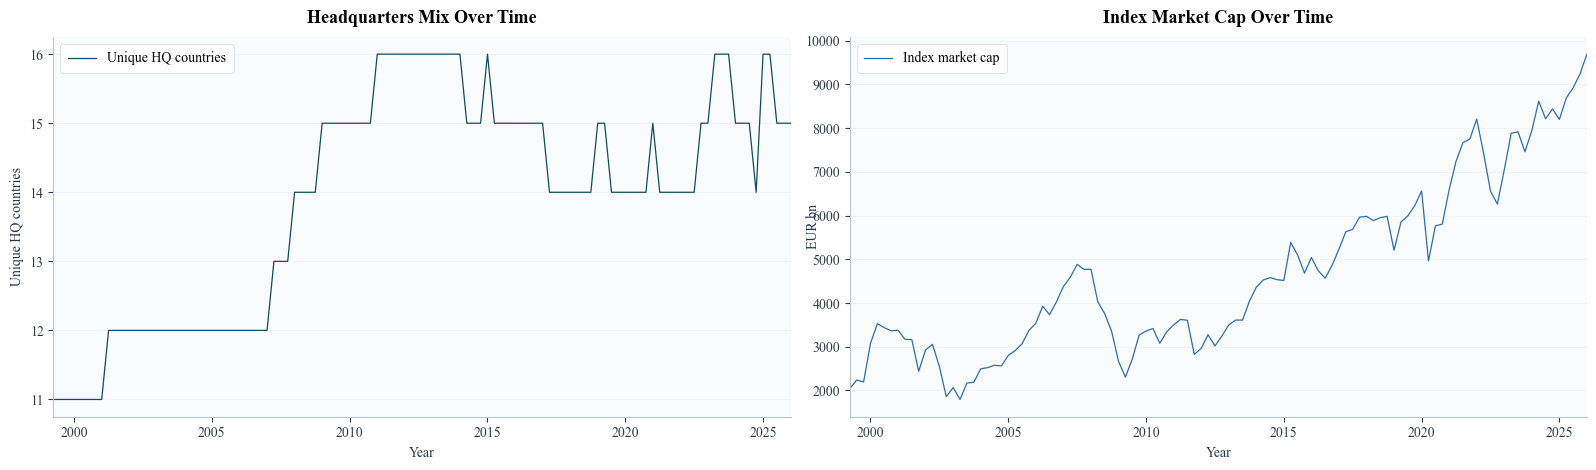

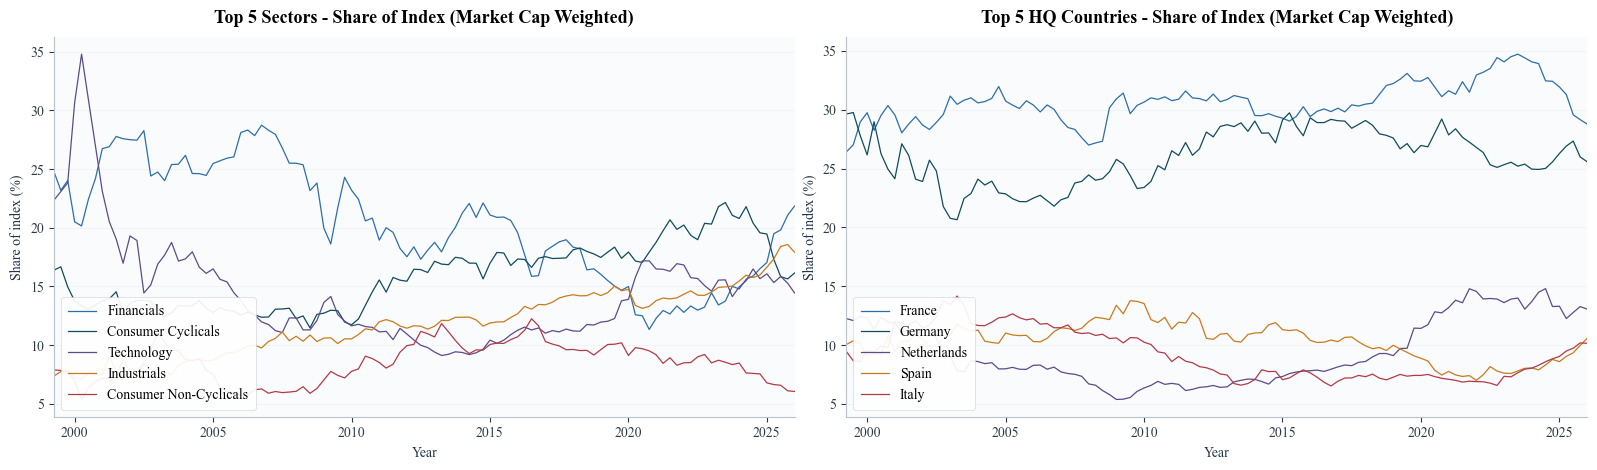

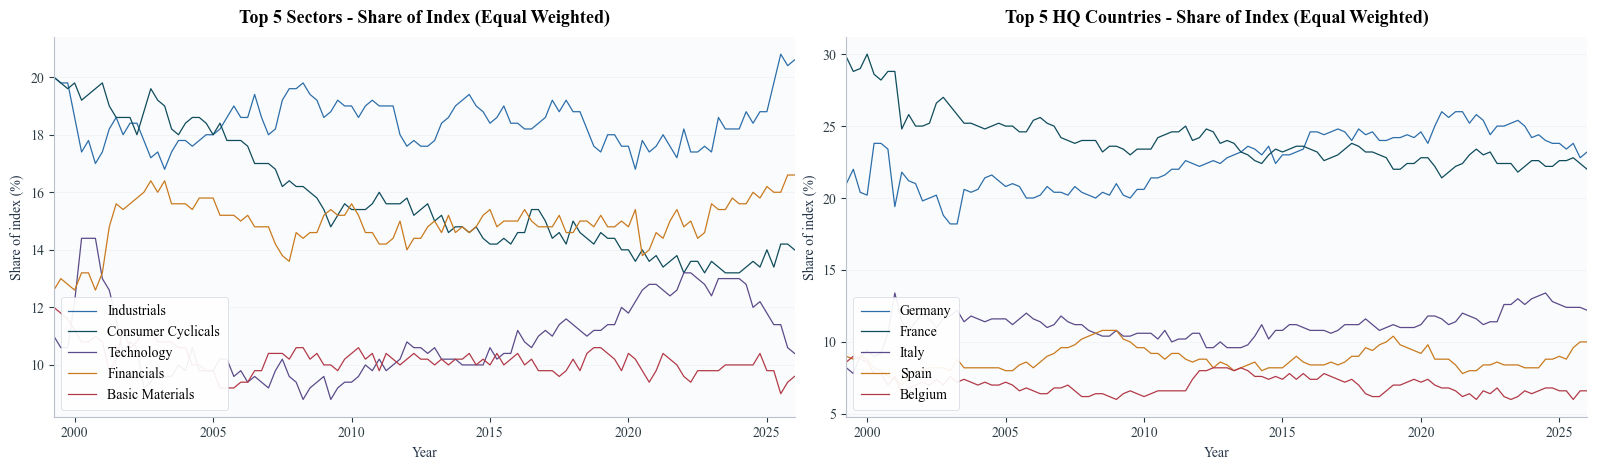

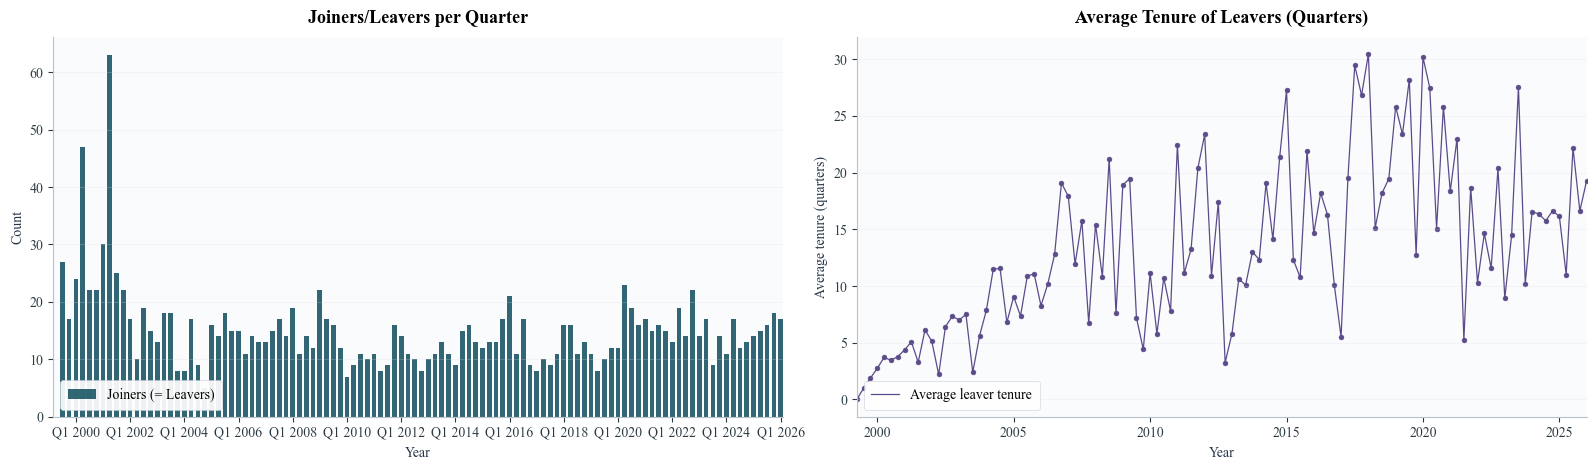

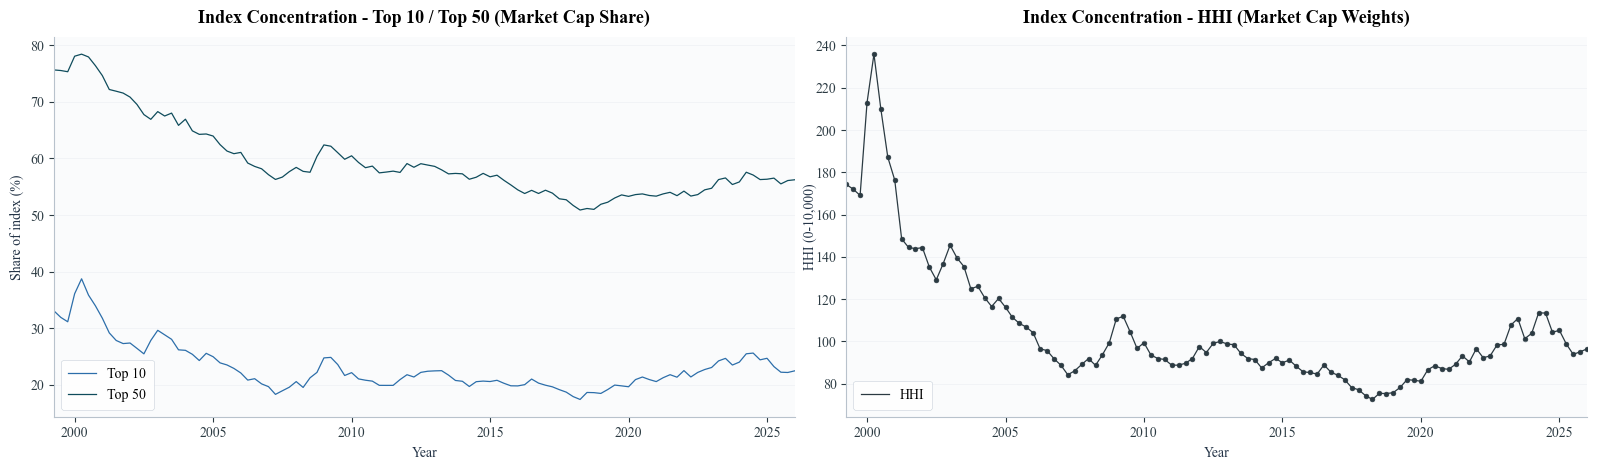

In [17]:
if "euro500" not in globals():
    raise RuntimeError("euro500 not found. Run portfolio construction sections first.")

base = euro500.copy()
base["date"] = pd.to_datetime(base["date"], errors="coerce")
base = base.dropna(subset=["date"]).copy()

base = base[base["date"] >= pd.Timestamp("1999-01-01")].copy()

if "quarter" in base.columns:
    base["q_label"] = base["quarter"].astype(str)
    base["q_period"] = pd.PeriodIndex(base["q_label"], freq="Q")
else:
    month = base["date"].dt.month
    qnum_map = {12: 1, 3: 2, 6: 3, 9: 4}
    q_num = month.map(qnum_map).fillna(((month - 1) // 3 + 1).astype(int))
    q_year = base["date"].dt.year + (month == 12).astype(int)
    base["q_label"] = q_year.astype(int).astype(str) + "Q" + q_num.astype(int).astype(str)
    base["q_period"] = pd.PeriodIndex(base["q_label"], freq="Q")

base = base[base["q_period"] >= pd.Period("1999Q1", freq="Q")].copy()
base = base.sort_values(["q_period", "date"]).copy()
quarter_order = (
    base[["q_label", "q_period"]]
    .drop_duplicates()
    .sort_values("q_period")
)
q_labels = quarter_order["q_label"].tolist()
q_index = {q: i for i, q in enumerate(q_labels)}

def _pretty_q_label(lbl: str) -> str:
    t = str(lbl)
    if "Q" in t:
        y, q = t.split("Q", 1)
        if y.isdigit() and q.isdigit():
            return f"Q{int(q)} {int(y)}"
    return t

if not q_labels:
    raise ValueError("No quarter labels available for time-variation analysis.")

if "BASE_DIR" not in globals():
    raise RuntimeError("BASE_DIR not found. Run setup section first.")
GRAPH_DIR = BASE_DIR / "graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

sector_col = "trbc_sector" if "trbc_sector" in base.columns else ("sector" if "sector" in base.columns else None)
hq_col = "hq_country" if "hq_country" in base.columns else ("hq_code" if "hq_code" in base.columns else None)

firm_id_col = None
for c in ["firm_id", "ISIN", "isin", "RIC"]:
    if c in base.columns:
        firm_id_col = c
        break
if firm_id_col is None:
    raise KeyError("No company-identifier column found (expected one of: firm_id, ISIN/isin, RIC).")

base["firm_key"] = base[firm_id_col].astype("string").str.strip()
base = base[base["firm_key"].notna() & (base["firm_key"] != "")].copy()

base["mcap_num"] = pd.to_numeric(base.get("mcap_eur", pd.Series(np.nan, index=base.index)), errors="coerce")

def _five_year_tick_pos(labels: list[str]) -> tuple[list[int], list[str]]:
    pos, txt = [], []
    last_year = None
    for i, lbl in enumerate(labels):
        try:
            y = int(str(lbl)[:4])
        except Exception:
            continue
        if y % 5 == 0 and y != last_year:
            pos.append(i)
            txt.append(str(y))
            last_year = y
    return pos, txt

def _apply_quarter_axis(ax, *, quarter_format: bool = False, max_ticks: int = 12):
    if quarter_format:
        tick_idx = []
        for i, lbl in enumerate(q_labels):
            t = str(lbl)
            if "Q" not in t:
                continue
            y, q = t.split("Q", 1)
            if y.isdigit() and q.isdigit() and int(y) >= 2000 and int(q) == 1 and (int(y) - 2000) % 2 == 0:
                tick_idx.append(i)
        if not tick_idx:
            step = max(1, len(q_labels) // max_ticks)
            tick_idx = list(range(0, len(q_labels), step))
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([_pretty_q_label(q_labels[i]) for i in tick_idx])
        return

    tick_pos, tick_txt = _five_year_tick_pos(q_labels)
    if tick_pos:
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_txt)
    else:
        step = max(1, len(q_labels) // 10)
        idx = list(range(0, len(q_labels), step))
        ax.set_xticks(idx)
        ax.set_xticklabels([q_labels[i] for i in idx], rotation=0)

# -------------------------
# Panel 1: HQ Mix & Market Cap
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

ax = axes[0]
if hq_col:
    hq_series = base.groupby("q_label")[hq_col].nunique().reindex(q_labels)
    ax.plot(range(len(q_labels)), hq_series.values, color=COLORS["primary"], lw=0.9, label="Unique HQ countries")
    ax.set_ylabel("Unique HQ countries")
    style_legend(ax, loc="upper left", frameon=True)
else:
    ax.text(0.5, 0.5, "No HQ data available", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Headquarters Mix Over Time")
ax.set_xlabel("Year")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")

ax = axes[1]
if base["mcap_num"].notna().any():
    mcap_series = base.groupby("q_label")["mcap_num"].sum().reindex(q_labels) / 1e9
    ax.plot(range(len(q_labels)), mcap_series.values, color=COLORS["blue"], lw=0.9, label="Index market cap")
    ax.set_ylabel("EUR bn")
    style_legend(ax, loc="upper left", frameon=True)
else:
    ax.text(0.5, 0.5, "No market cap data available", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Index Market Cap Over Time")
ax.set_xlabel("Year")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")

plt.tight_layout()
fig.savefig(GRAPH_DIR / "euro500_timevariation_panel1_hq_mcap.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------
# Panel 2: Top-5 MCAP weighted shares
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
line_palette = [COLORS["blue"], COLORS["primary"], COLORS["purple"], COLORS["orange"], COLORS["accent"]]

ax = axes[0]
if sector_col and base["mcap_num"].notna().any():
    tot_sector = base.groupby(sector_col)["mcap_num"].sum().sort_values(ascending=False)
    top5_sector = tot_sector.head(5).index.tolist()
    by_q_sector = base.groupby(["q_label", sector_col])["mcap_num"].sum().reset_index(name="mcap")
    by_q_total = base.groupby("q_label")["mcap_num"].sum().reset_index(name="mcap_total")
    by_q_sector = by_q_sector.merge(by_q_total, on="q_label", how="left")
    by_q_sector["share"] = np.where(by_q_sector["mcap_total"] > 0, 100.0 * by_q_sector["mcap"] / by_q_sector["mcap_total"], np.nan)
    for i, sec in enumerate(top5_sector):
        s = by_q_sector.loc[by_q_sector[sector_col] == sec, ["q_label", "share"]].set_index("q_label")["share"].reindex(q_labels)
        ax.plot(range(len(q_labels)), s.values, lw=0.9, color=line_palette[i % len(line_palette)], label=str(sec))
    style_legend(ax, loc="lower left", frameon=True)
else:
    ax.text(0.5, 0.5, "No sector market-cap data available", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Top 5 Sectors - Share of Index (Market Cap Weighted)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of index (%)")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")

ax = axes[1]
if hq_col and base["mcap_num"].notna().any():
    tot_country = base.groupby(hq_col)["mcap_num"].sum().sort_values(ascending=False)
    top5_country = tot_country.head(5).index.tolist()
    by_q_country = base.groupby(["q_label", hq_col])["mcap_num"].sum().reset_index(name="mcap")
    by_q_total = base.groupby("q_label")["mcap_num"].sum().reset_index(name="mcap_total")
    by_q_country = by_q_country.merge(by_q_total, on="q_label", how="left")
    by_q_country["share"] = np.where(by_q_country["mcap_total"] > 0, 100.0 * by_q_country["mcap"] / by_q_country["mcap_total"], np.nan)
    for i, ctry in enumerate(top5_country):
        s = by_q_country.loc[by_q_country[hq_col] == ctry, ["q_label", "share"]].set_index("q_label")["share"].reindex(q_labels)
        ax.plot(range(len(q_labels)), s.values, lw=0.9, color=line_palette[i % len(line_palette)], label=str(ctry))
    style_legend(ax, loc="lower left", frameon=True)
else:
    ax.text(0.5, 0.5, "No HQ market-cap data available", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Top 5 HQ Countries - Share of Index (Market Cap Weighted)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of index (%)")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")

plt.tight_layout()
fig.savefig(GRAPH_DIR / "euro500_timevariation_panel2_top5_mcap_weighted.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------
# Panel 3: Top-5 Equal-weighted shares
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

ax = axes[0]
if sector_col:
    tot_sector_n = base.groupby(sector_col)["firm_key"].nunique().sort_values(ascending=False)
    top5_sector_n = tot_sector_n.head(5).index.tolist()
    by_q_sector_n = base.groupby(["q_label", sector_col])["firm_key"].nunique().reset_index(name="n")
    by_q_total_n = base.groupby("q_label")["firm_key"].nunique().reset_index(name="n_total")
    by_q_sector_n = by_q_sector_n.merge(by_q_total_n, on="q_label", how="left")
    by_q_sector_n["share"] = np.where(by_q_sector_n["n_total"] > 0, 100.0 * by_q_sector_n["n"] / by_q_sector_n["n_total"], np.nan)
    for i, sec in enumerate(top5_sector_n):
        s = by_q_sector_n.loc[by_q_sector_n[sector_col] == sec, ["q_label", "share"]].set_index("q_label")["share"].reindex(q_labels)
        ax.plot(range(len(q_labels)), s.values, lw=0.9, color=line_palette[i % len(line_palette)], label=str(sec))
    style_legend(ax, loc="lower left", frameon=True)
else:
    ax.text(0.5, 0.5, "No sector data available", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Top 5 Sectors - Share of Index (Equal Weighted)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of index (%)")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")

ax = axes[1]
if hq_col:
    tot_country_n = base.groupby(hq_col)["firm_key"].nunique().sort_values(ascending=False)
    top5_country_n = tot_country_n.head(5).index.tolist()
    by_q_country_n = base.groupby(["q_label", hq_col])["firm_key"].nunique().reset_index(name="n")
    by_q_total_n = base.groupby("q_label")["firm_key"].nunique().reset_index(name="n_total")
    by_q_country_n = by_q_country_n.merge(by_q_total_n, on="q_label", how="left")
    by_q_country_n["share"] = np.where(by_q_country_n["n_total"] > 0, 100.0 * by_q_country_n["n"] / by_q_country_n["n_total"], np.nan)
    for i, ctry in enumerate(top5_country_n):
        s = by_q_country_n.loc[by_q_country_n[hq_col] == ctry, ["q_label", "share"]].set_index("q_label")["share"].reindex(q_labels)
        ax.plot(range(len(q_labels)), s.values, lw=0.9, color=line_palette[i % len(line_palette)], label=str(ctry))
    style_legend(ax, loc="lower left", frameon=True)
else:
    ax.text(0.5, 0.5, "No HQ data available", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Top 5 HQ Countries - Share of Index (Equal Weighted)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of index (%)")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")

plt.tight_layout()
fig.savefig(GRAPH_DIR / "euro500_timevariation_panel3_top5_equal_weighted.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------
# Panel 4: Turnover and Leaver Tenure
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

by_q_set = base.groupby("q_label")["firm_key"].agg(lambda s: set(s.dropna().tolist()))
records_turnover = []
records_tenure = []
prev_set = set()
prev_streak = {}

for i, q in enumerate(q_labels):
    cur_set = by_q_set.get(q, set())
    joiners = len(cur_set - prev_set) if i > 0 else 0
    leavers = len(prev_set - cur_set) if i > 0 else 0
    records_turnover.append({"q_label": q, "joiners": joiners, "leavers": leavers})

    if i == 0:
        records_tenure.append({"q_label": q, "avg_tenure_q": 0.0})
        prev_streak = {k: 1 for k in cur_set}
    else:
        leaver_keys = prev_set - cur_set
        tenures = [float(prev_streak.get(k, 0)) for k in leaver_keys if prev_streak.get(k, 0) > 0]
        avg_tenure = float(pd.Series(tenures).mean()) if tenures else 0.0
        records_tenure.append({"q_label": q, "avg_tenure_q": avg_tenure})

        cur_streak = {}
        for k in cur_set:
            cur_streak[k] = prev_streak.get(k, 0) + 1 if k in prev_set else 1
        prev_streak = cur_streak

    prev_set = cur_set

turnover_df = pd.DataFrame(records_turnover)
tenure_df = pd.DataFrame(records_tenure)

ax = axes[0]
ax.bar(range(len(q_labels)), turnover_df["joiners"].values, color=COLORS["primary"], alpha=0.85, width=0.7, label="Joiners (= Leavers)")
ax.set_title("Joiners/Leavers per Quarter")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
_apply_quarter_axis(ax, quarter_format=True)
style_axes(ax, grid_axis="y")
style_legend(ax, loc="lower left", frameon=True)

ax = axes[1]
ax.plot(range(len(q_labels)), tenure_df["avg_tenure_q"].values, color=COLORS["purple"], lw=0.9, label="Average leaver tenure")
ax.scatter(range(len(q_labels)), tenure_df["avg_tenure_q"].values, color=COLORS["purple"], s=12)
ax.set_title("Average Tenure of Leavers (Quarters)")
ax.set_xlabel("Year")
ax.set_ylabel("Average tenure (quarters)")
_apply_quarter_axis(ax)
style_axes(ax, grid_axis="y")
style_legend(ax, loc="lower left", frameon=True)

plt.tight_layout()
fig.savefig(GRAPH_DIR / "euro500_timevariation_panel4_turnover_tenure.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------
# Panel 5: Concentration (TopN and HHI)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

if base["mcap_num"].notna().any():
    agg = base.dropna(subset=["mcap_num"]).groupby(["q_label", "firm_key"], as_index=False)["mcap_num"].max()

    topn_records = []
    hhi_records = []
    for q in q_labels:
        s = agg.loc[agg["q_label"] == q, "mcap_num"].sort_values(ascending=False)
        total = float(s.sum()) if len(s) else 0.0
        top10 = (float(s.head(10).sum()) / total) * 100 if total > 0 else 0.0
        top50 = (float(s.head(50).sum()) / total) * 100 if total > 0 else 0.0
        hhi = float(((s / total).pow(2).sum()) * 10000.0) if total > 0 else 0.0
        topn_records.append({"q_label": q, "top10": top10, "top50": top50})
        hhi_records.append({"q_label": q, "hhi": hhi})

    topn_df = pd.DataFrame(topn_records)
    hhi_df = pd.DataFrame(hhi_records)

    ax = axes[0]
    ax.plot(range(len(q_labels)), topn_df["top10"].values, color=COLORS["blue"], lw=0.9, label="Top 10")
    ax.plot(range(len(q_labels)), topn_df["top50"].values, color=COLORS["primary"], lw=0.9, label="Top 50")
    ax.set_title("Index Concentration - Top 10 / Top 50 (Market Cap Share)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of index (%)")
    _apply_quarter_axis(ax)
    style_axes(ax, grid_axis="y")
    style_legend(ax, loc="lower left", frameon=True)

    ax = axes[1]
    ax.plot(range(len(q_labels)), hhi_df["hhi"].values, color=COLORS.get("reference", "#2B3A42"), lw=0.9, label="HHI")
    ax.scatter(range(len(q_labels)), hhi_df["hhi"].values, color=COLORS.get("reference", "#2B3A42"), s=12)
    ax.set_title("Index Concentration - HHI (Market Cap Weights)")
    ax.set_xlabel("Year")
    ax.set_ylabel("HHI (0-10,000)")
    _apply_quarter_axis(ax)
    style_axes(ax, grid_axis="y")
    style_legend(ax, loc="lower left", frameon=True)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "No valid market cap data available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()

plt.tight_layout()
fig.savefig(GRAPH_DIR / "euro500_timevariation_panel5_concentration.png", dpi=220, bbox_inches="tight")
plt.show()


### 3.1 STOXX600 EuroHQ vs EURO500 (Name Overlap, Static)

This subsection compares simple company-name coverage between:
- The full STOXX600 EuroHQ membership matrix (all available rows)
- The EURO500 universe

No quarterly or time dimension is used.


Static name overlap summary (no time dimension):


,n_stoxx_unique_names,n_euro500_unique_names,n_intersection,share_stoxx_covered_by_euro500,share_euro500_covered_by_stoxx
0,650,1252,421,0.647692,0.336262


Year-count table: years in STOXX for names missing in EURO500 (top 20)


,NAME_norm,n_years_in_stx
0,EXPERIANPLC,27
1,FRONTLINEPLC,27
2,ABNAMROBANKNV,27
3,BMEUROPEANVALUERETAILSA,27
4,UNIBAILRODAMCOWESTFIELDSE,27
5,ALLEGROEUSA,27
6,DCCPLC,27
7,DSMBV,24
8,VALMETOYJ,23
9,CNPASSURANCESSA,23


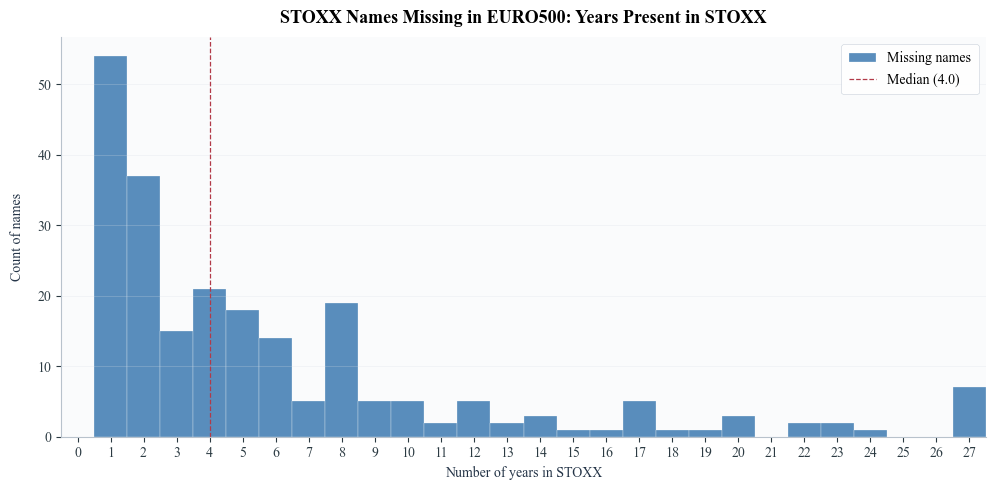

In [14]:
STOXX_EUROHQ_PATH = DATA_DIR / "stoxx600_membership_matrix_1999_2025_eurohq.parquet"
if not STOXX_EUROHQ_PATH.exists():
    raise FileNotFoundError(f"Missing file: {STOXX_EUROHQ_PATH}")

stx = pd.read_parquet(STOXX_EUROHQ_PATH).copy()
euro_cmp = euro500.copy()

def normalize_name(x: pd.Series) -> pd.Series:
    s = x.astype(str).str.strip().str.upper()
    # Robust against punctuation and whitespace variants.
    s = s.str.replace(r"[^A-Z0-9]+", "", regex=True)
    s = s.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    return s

if "CompanyName" not in stx.columns:
    raise KeyError("Column 'CompanyName' not found in STOXX matrix.")

name_col_euro = "name" if "name" in euro_cmp.columns else ("CompanyName" if "CompanyName" in euro_cmp.columns else None)
if name_col_euro is None:
    raise KeyError("No company-name column found in euro500 (expected 'name' or 'CompanyName').")

# -------- Static name overlap (no time dimension) --------
stx_names = normalize_name(stx["CompanyName"]).dropna()
euro_names = normalize_name(euro_cmp[name_col_euro]).dropna()

stx_set = set(stx_names.astype(str))
euro_set = set(euro_names.astype(str))
intersection = stx_set & euro_set

name_overlap_summary = pd.DataFrame([
    {
        "n_stoxx_unique_names": len(stx_set),
        "n_euro500_unique_names": len(euro_set),
        "n_intersection": len(intersection),
        "share_stoxx_covered_by_euro500": (len(intersection) / len(stx_set)) if stx_set else np.nan,
        "share_euro500_covered_by_stoxx": (len(intersection) / len(euro_set)) if euro_set else np.nan,
    }
])

stx_not_in_euro500 = pd.DataFrame({"NAME_norm": sorted(stx_set - euro_set)})
euro500_not_in_stx = pd.DataFrame({"NAME_norm": sorted(euro_set - stx_set)})

print("Static name overlap summary (no time dimension):")
display(name_overlap_summary)

# -------- Year-based distribution for missing names --------
year_cols = [c for c in stx.columns if str(c).isdigit()]
if not year_cols:
    raise ValueError("No year columns found in STOXX membership matrix.")

stx_year = stx[["CompanyName", *year_cols]].copy()
stx_year["NAME_norm"] = normalize_name(stx_year["CompanyName"])

for c in year_cols:
    stx_year[c] = pd.to_numeric(stx_year[c], errors="coerce").fillna(0).astype(int)

# Collapse potential duplicates at normalized-name level
name_year_membership = stx_year.groupby("NAME_norm")[year_cols].max()

records = []
for name_key in stx_not_in_euro500["NAME_norm"]:
    n_years = 0
    if name_key in name_year_membership.index:
        row = name_year_membership.loc[name_key]
        n_years = int((row == 1).sum())
    records.append({"NAME_norm": name_key, "n_years_in_stx": n_years})

stx_not_in_euro500_year_counts = pd.DataFrame(records).sort_values(
    "n_years_in_stx", ascending=False
).reset_index(drop=True)

print("Year-count table: years in STOXX for names missing in EURO500 (top 20)")
display(stx_not_in_euro500_year_counts.head(20))

max_y = int(stx_not_in_euro500_year_counts["n_years_in_stx"].max()) if len(stx_not_in_euro500_year_counts) else 0
bins = range(0, max_y + 2)
median_years = float(stx_not_in_euro500_year_counts["n_years_in_stx"].median()) if len(stx_not_in_euro500_year_counts) else 0.0

fig, ax = plt.subplots(figsize=(10, 5.0))
ax.hist(
    stx_not_in_euro500_year_counts["n_years_in_stx"],
    bins=bins,
    color=COLORS["blue"],
    alpha=0.78,
    edgecolor="white",
    linewidth=0.25,
    align="left",
    label="Missing names",
)
ax.axvline(median_years, color=COLORS["accent"], linewidth=0.9, linestyle="--", label=f"Median ({median_years:.1f})")

ax.set_title("STOXX Names Missing in EURO500: Years Present in STOXX", fontsize=13, pad=10)
ax.set_xlabel("Number of years in STOXX")
ax.set_ylabel("Count of names")
if max_y > 0:
    step = max(1, max_y // 20)
    ax.set_xticks(range(0, max_y + 1, step))
style_axes(ax, grid_axis="y", label_x=-0.04, label_y=0.5, label_pad=1)
style_legend(ax, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## 4. Dashboard Export Copy

Final preparation step for dashboard usage.

What is created:
- Clean copy of the main output tables
- Stable file names/paths for downstream app loading
- Minimal schema checks before export


In [15]:
# --- Exportfenster: 1999Q1 bis heute ---
EXPORT_START_Q = pd.Period("1999Q1")
TODAY = pd.Timestamp.today().normalize()

export_base = euro500.copy()
export_base["quarter"] = export_base["quarter"].astype(str)
export_base["quarter_p"] = pd.PeriodIndex(export_base["quarter"], freq="Q")
export_base["date"] = pd.to_datetime(export_base["date"], errors="coerce")
export_base = export_base[
    (export_base["quarter_p"] >= EXPORT_START_Q)
    & (export_base["date"].notna())
    & (export_base["date"] <= TODAY)
].copy()

# --- gewünschte Spalten auswählen ---
export_df = export_base[[
    "date",
    "name",
    "hq_country",
    "trbc_sector",
    "mcap_eur",
    "ISIN",
    "rank_mcap",
    "firm_id"
]].copy()

# Umbenennen
export_df = export_df.rename(columns={
    "trbc_sector": "sector",
    "ISIN": "isin"
})

# --- mcap: letzte 6 Ziffern auf 0 setzen ---
# Beispiel: 1234567890 -> 1234000000
export_df["mcap_eur"] = (
    (export_df["mcap_eur"] // 1_000_000) * 1_000_000
).astype("Int64")

# --- Speicherpfad auf deinem Mac ---
output_path = Path(
    "/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/EURO500 Dashboard/euro500_dashboard_table.parquet"
)

# Ordner sicherstellen
output_path.parent.mkdir(parents=True, exist_ok=True)

# Speichern
export_df.to_parquet(output_path, index=False)